# Chip Dynamics — Batch Results Analysis

Load and explore CSV tables produced by **`batch_chip_dynamics.py`**.
Each CSV in the output directory represents one (CZI file × scene × channel) pair
and contains all detected objects across all timepoints.

Sections
--------
1. Configuration & Load
2. Summary table
3. Temporal dynamics — object count & area over time
4. Band occupancy — inside vs outside the microfluidic channel
5. Cell size distribution per timepoint
6. Spatial density heatmap
7. Export filtered results


## 1 · Configuration & Load

In [7]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

%load_ext autoreload
%autoreload 2
%matplotlib widget


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — edit this cell
# ════════════════════════════════════════════════════════════════════════════

# Directory that was passed as --output to batch_chip_dynamics.py
RESULTS_DIR = Path("/Volumes/vangestel/Coco/ZeissData/ICP/results")   # ← change

# Optional filters applied after loading (None = no filter)
FILTER_ORGANISM   = None   # e.g. "dictyostelium" or None
FILTER_CZI        = None   # substring match on czi_file name, or None

# Size / distance filters for all downstream plots
SEL_AREA_MIN_UM2 = 25.0    # minimum object area (µm²)
SEL_AREA_MAX_UM2 = None    # maximum object area  (None = no limit)
SEL_DIST_MAX_UM  = None    # max |distance to band centre| in µm (None = all)

# Colour palette: organism → matplotlib colour
ORG_COLORS = {
    "dictyostelium": "#1f77b4",
    "celegans":      "#2ca02c",
    "physarum":      "#d62728",
}


## 10 · ICP2 deep-dive — tracks + channel boundaries + per-track MSD fits


In [9]:

from chipanalysis.functions.chip_dynamics_analysis import (
    load_results, add_tracks, fit_msd,
    plot_tracks_on_video, plot_summary, plot_size_vs_distance,
)

# ── Parameters ────────────────────────────────────────────────────────────────
EXPERIMENTS     = "ICP12"        # substring, list of substrings, or None (= all)
VIZ_SCENE       = None          # None = all scenes; int = specific scene

SEL_AREA_MIN_UM2
# ── Load ──────────────────────────────────────────────────────────────────────
df = load_results(RESULTS_DIR, experiments=EXPERIMENTS, scene=VIZ_SCENE,
                  area_min_um2=SEL_AREA_MIN_UM2)




Loaded 93,855 rows | 1 experiments | timepoints 0–96


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_92348/4044554382.py:31: RuntimeWarning: divide by zero encountered in log10
  H2d_norm = np.log10(H2d / n_tp)   # normalise by number of timepoints


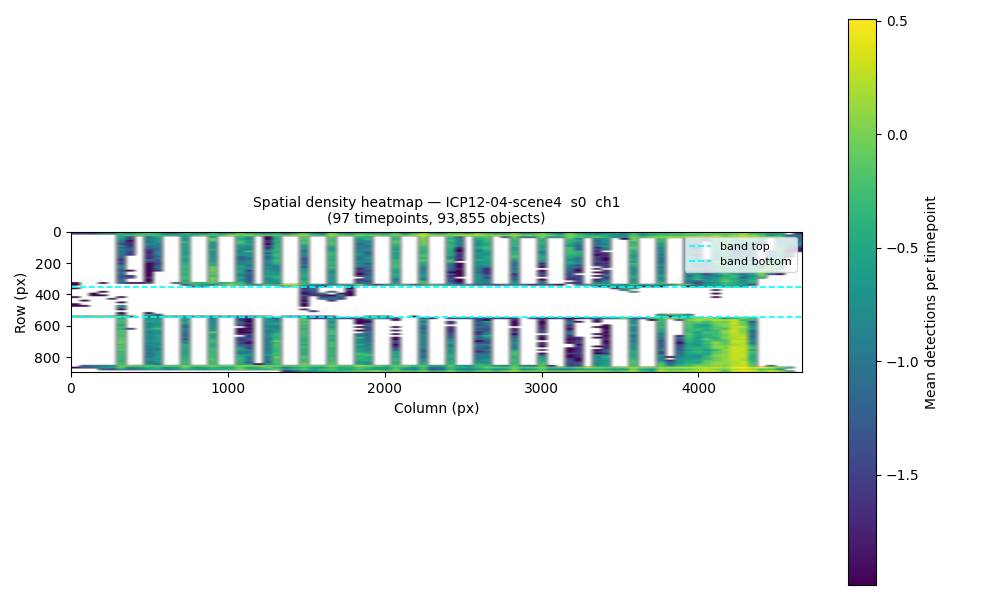

In [10]:
# ── Parameters ────────────────────────────────────────────────────────────────
HEATMAP_EXPERIMENT = df["experiment"].unique()[0]   # pick one experiment
HEATMAP_N_BINS     = 80        # spatial histogram bins (rows & cols)
SHOW_ON_IMAGE      = False     # True → overlay on BF image (needs CZI access)

# Optional: load BF reference image from the CZI for overlay
# (fill in CZI_PATH, SCENE, CHANNEL_BF if SHOW_ON_IMAGE = True)
CZI_PATH_HEATMAP  = None   # e.g. "/path/to/file.czi"
SCENE_HEATMAP     = 1
CHANNEL_BF_HEATMAP = 2

# ── Build heatmap ─────────────────────────────────────────────────────────────
sub = df[df["experiment"] == HEATMAP_EXPERIMENT]

if sub.empty:
    print("No data for selected experiment.")
else:
    row_vals = sub["centroid_row"].values
    col_vals = sub["centroid_col"].values
    n_tp     = sub["timepoint"].nunique()

    # Auto-detect image bounds from data
    row_max = int(np.ceil(row_vals.max())) + 1
    col_max = int(np.ceil(col_vals.max())) + 1

    H2d, row_edges, col_edges = np.histogram2d(
        row_vals, col_vals,
        bins=HEATMAP_N_BINS,
        range=[[0, row_max], [0, col_max]],
    )
    H2d_norm = np.log10(H2d / n_tp)   # normalise by number of timepoints

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))

    if SHOW_ON_IMAGE and CZI_PATH_HEATMAP is not None:
        from chipanalysis.functions.chip_dynamics import load_czi, get_rotation_fn, get_rotated_frame
        _czi, _px, _, _ = load_czi(CZI_PATH_HEATMAP)
        _rfn, _ = get_rotation_fn(_czi, bf_channel=CHANNEL_BF_HEATMAP,
                                  scene=SCENE_HEATMAP, px_um=_px)
        _img, _ = get_rotated_frame(_czi, 0, CHANNEL_BF_HEATMAP, SCENE_HEATMAP, _rfn)
        ax.imshow(_img, cmap="gray", origin="upper",
                  extent=[0, col_max, row_max, 0], zorder=0)
        cmap_heat = "hot"
        alpha_heat = 0.65
    else:
        cmap_heat = "viridis"
        alpha_heat = 1.0

    extent = [col_edges[0], col_edges[-1], row_edges[-1], row_edges[0]]
    im = ax.imshow(H2d_norm, origin="upper", extent=extent,
                   cmap=cmap_heat, alpha=alpha_heat, zorder=1)
    plt.colorbar(im, ax=ax, label="Mean detections per timepoint")

    # Band boundaries from first row of this experiment
    row0 = sub.iloc[0]
    if "band_top_px" in row0.index:
        ax.axhline(row0["band_top_px"],    color="cyan", lw=1.2, ls="--", label="band top")
        ax.axhline(row0["band_bottom_px"], color="cyan", lw=1.2, ls="--", label="band bottom")
        ax.legend(fontsize=8)

    ax.set_xlabel("Column (px)")
    ax.set_ylabel("Row (px)")
    ax.set_title(
        f"Spatial density heatmap — {HEATMAP_EXPERIMENT}\n"
        f"({n_tp} timepoints, {len(sub):,} objects)",
        fontsize=10,
    )
    plt.tight_layout(); plt.show()


In [11]:
AREA_WEIGHT     = 0.1
MIN_LEN         = 1             # minimum track length (timepoints)
MAX_SPEED_UM_H  = 300.0   # µm/h — dynamic spatial gate per frame

# ── Track ─────────────────────────────────────────────────────────────────────
df = add_tracks(df, max_speed_um_h=MAX_SPEED_UM_H,
                area_weight=AREA_WEIGHT, min_len=MIN_LEN)

# ── MSD fits ──────────────────────────────────────────────────────────────────
df_fits = fit_msd(df, min_pts=4, max_frac=0.5, min_r2=0.7)

  ICP12-04-scene4  s0  ch1  →  14,699 raw tracks

After min_len ≥ 1: 14,699 tracks  (93,855 detections)
Fitted 3,762 tracks → 2,970 pass quality filter (R²≥0.7, α>0, D>0)
  α  median=0.81  mean=0.84
  D  median=457.3710  mean=621.5799  µm²/h^α


Video: ICP12-04-scene4_scene0_ch1_video.mp4  frame 0/96  4096×744 px  scale=0.8312


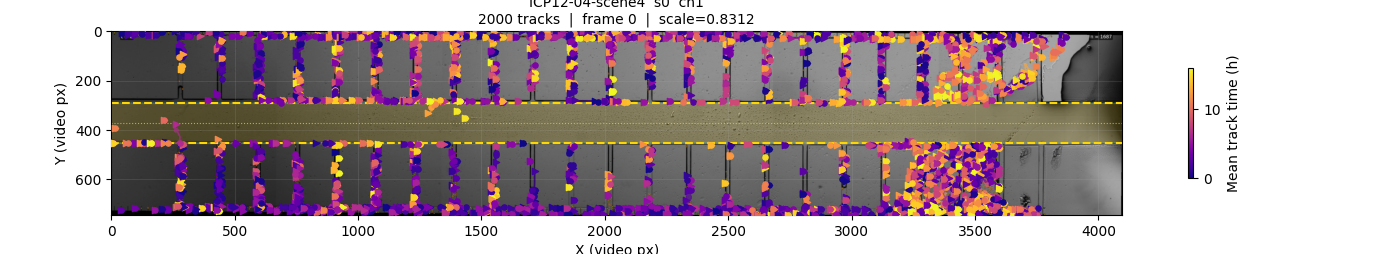

In [12]:

# ── Video overlay — pick experiment and frame ─────────────────────────────────
VID_EXPERIMENT = df['experiment'].unique()[0]   # ← change as needed
VID_FRAME_IDX  = 0                              # 0 = first frame

fig = plot_tracks_on_video(
    df, RESULTS_DIR,
    experiment=VID_EXPERIMENT,
    frame_idx=VID_FRAME_IDX,
    max_tracks=2000,
)
plt.show()


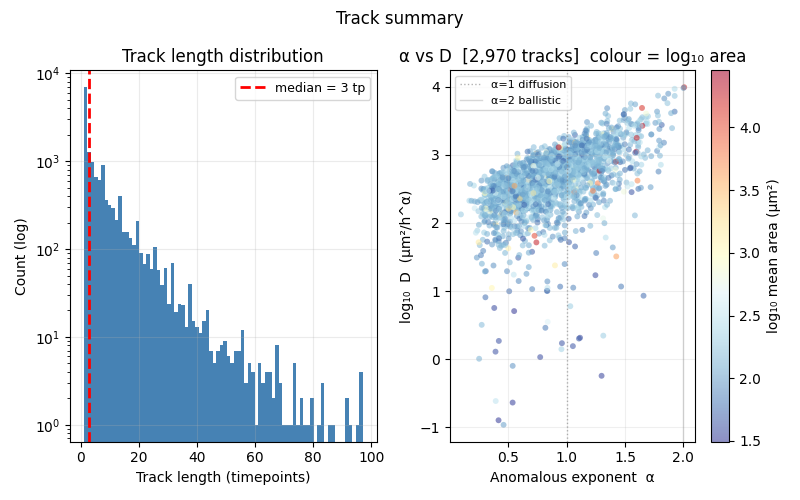

In [13]:

# ── Summary: track-length histogram + α vs D coloured by size ────────────────
fig = plot_summary(df, df_fits)
plt.show()


Plotting 54,947 detections from 2,945 tracks (α∈(0.0, inf), D∈(10.0, inf))


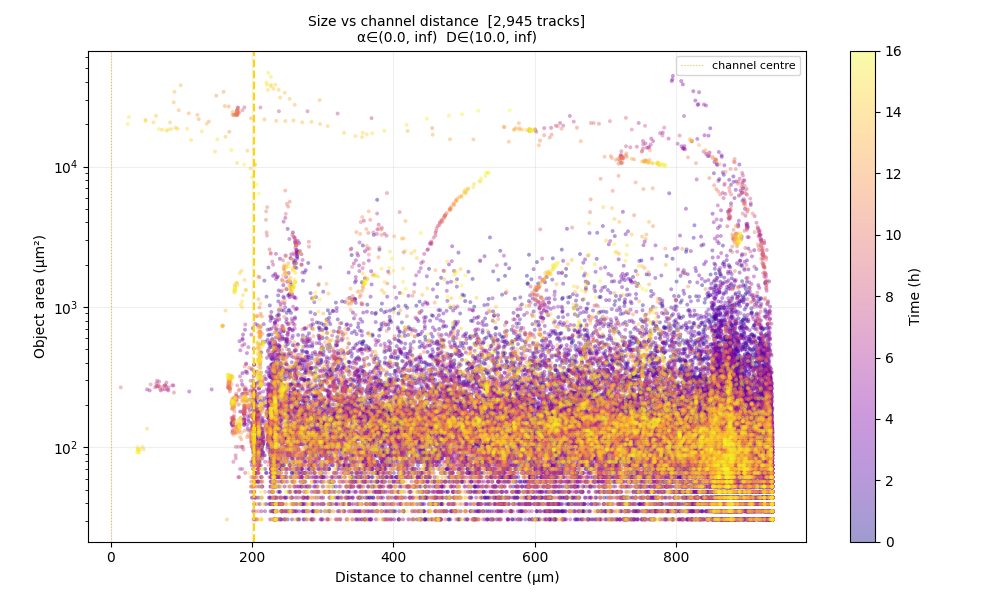

In [14]:

# ── Size vs distance to channel, filtered by α/D range ───────────────────────
ALPHA_RANGE = (0.0, np.inf)    # (min, max) — set e.g. (0.8, 1.5) to focus on near-diffusive
D_RANGE     = (1e1, np.inf)    # (min, max) in µm²/h^α

fig,ax = plot_size_vs_distance(df, df_fits,
                            alpha_range=ALPHA_RANGE,
                            D_range=D_RANGE)
ax.set_yscale("log")
plt.show()


54,947 detections from 2,945 tracks


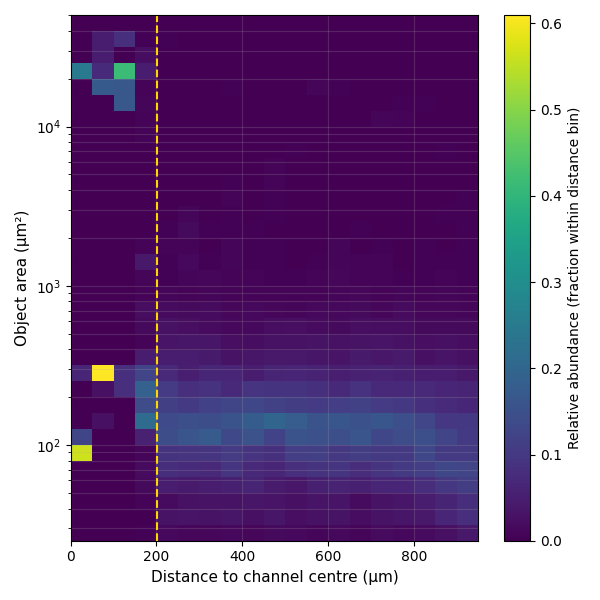

In [21]:
# ── Parameters ────────────────────────────────────────────────────────────────
ALPHA_RANGE           = (0.0, np.inf)
D_RANGE               = (1e1, np.inf)
DIST_BIN_UM           = 50.0    # linear distance bin width (µm)
LOG_RESOLUTION_DECADE = 0.1     # size bin width in log10 units (0.1 = tenth of decade)

# ── Filter ────────────────────────────────────────────────────────────────────
mask = (
    (df_fits["alpha"] >= ALPHA_RANGE[0]) & (df_fits["alpha"] <= ALPHA_RANGE[1])
    & (df_fits["D"]   >= D_RANGE[0])     & (df_fits["D"]   <= D_RANGE[1])
)
good_tracks = df_fits.loc[mask, "track_id"]
sub = df[df["track_id"].isin(good_tracks)].copy()
sub["dist_abs_um"] = np.abs(sub["dist_to_band_um"])
print(f"{len(sub):,} detections from {sub['track_id'].nunique():,} tracks")

# ── Bins ──────────────────────────────────────────────────────────────────────
dist_vals = sub["dist_abs_um"].values
area_vals = sub["area_um2"].values

# x: linear distance bins
dist_max  = np.ceil(dist_vals.max() / DIST_BIN_UM) * DIST_BIN_UM
dist_bins = np.arange(0, dist_max + DIST_BIN_UM, DIST_BIN_UM)

# y: log-spaced size bins, snapped to LOG_RESOLUTION_DECADE grid
log_min   = np.floor(np.log10(area_vals.min()) / LOG_RESOLUTION_DECADE) * LOG_RESOLUTION_DECADE
log_max   = np.ceil( np.log10(area_vals.max()) / LOG_RESOLUTION_DECADE) * LOG_RESOLUTION_DECADE
size_bins = 10 ** np.arange(log_min, log_max + LOG_RESOLUTION_DECADE, LOG_RESOLUTION_DECADE)

# ── 2D histogram ──────────────────────────────────────────────────────────────
# H shape: (n_dist_bins, n_size_bins)
H, dist_edges, size_edges = np.histogram2d(
    dist_vals, area_vals, bins=[dist_bins, size_bins]
)

# Normalise within each distance column → fraction of objects per size bin
col_totals = H.sum(axis=1, keepdims=True)          # (n_dist, 1)
H_norm = np.where(col_totals > 0, H / col_totals, np.nan)
# H_norm[i, j] = fraction of objects at distance i that are in size bin j

# ── Plot with pcolormesh (handles log-y correctly) ────────────────────────────
band_half_um = float(sub["band_width_um"].iloc[0]) / 2.0

fig, ax = plt.subplots(figsize=(6, 6))
# fig,ax = plot_size_vs_distance(df, df_fits,
#                             alpha_range=ALPHA_RANGE,
#                             D_range=D_RANGE)
mesh = ax.pcolormesh(
    dist_edges,   # (n_dist+1,)  x bin edges
    size_edges,   # (n_size+1,)  y bin edges — pcolormesh uses real data coords
    H_norm.T,     # (n_size, n_dist)  C[j,i] = fraction in size bin j, dist bin i
    cmap="viridis",
    shading="flat",
    alpha = 1
)

ax.set_yscale("log")
ax.axvline(band_half_um, color="gold",     lw=1.5, ls="--", label=f"channel edge ({band_half_um:.0f} µm)")
ax.axvline(0,            color="goldenrod", lw=0.8, ls=":",  alpha=0.7, label="channel centre")

plt.colorbar(mesh, ax=ax, label="Relative abundance (fraction within distance bin)")
ax.set_xlabel("Distance to channel centre (µm)", fontsize=11)
ax.set_ylabel("Object area (µm²)",               fontsize=11)

# ax.legend(fontsizek=8)
ax.grid(True, alpha=0.2, which="both")
fig.tight_layout()
plt.show()